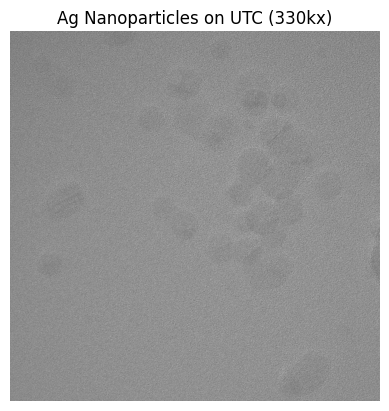

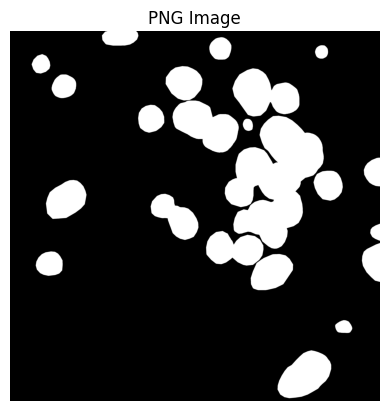

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()


img = mpimg.imread(label_file)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [2]:
from skimage.util import view_as_blocks

def split_patches(patch_size, image):
    blocks = view_as_blocks(image, block_shape=(patch_size, patch_size))
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [3]:
patched_image = split_patches(16, image_data)

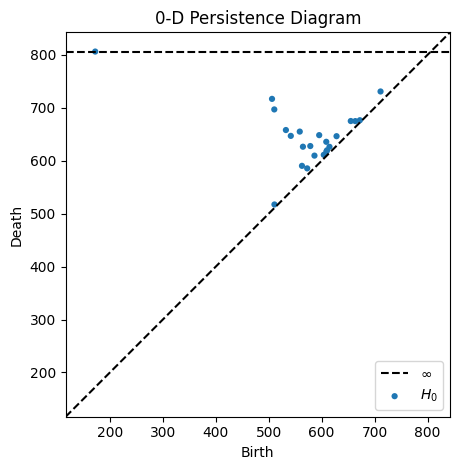

In [17]:
from persim import plot_diagrams
from ripser import lower_star_img

dgm = lower_star_img(patched_image[0])
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()


In [4]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(400, 700),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)
    return dgms, vectors

dgms, vectorised_patches = PH_patch(patched_image)


In [86]:
print(vectorised_patches.shape)

(65536, 2242)


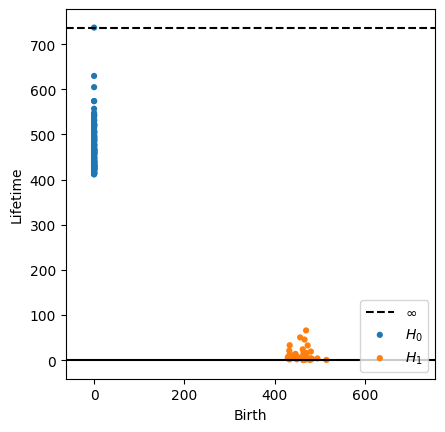

In [9]:
import ripser 

r = ripser.ripser(vectorised_patches, maxdim=1,n_perm=200)
dgms = r['dgms']
plot_diagrams(dgms, show=True, lifetime=True)

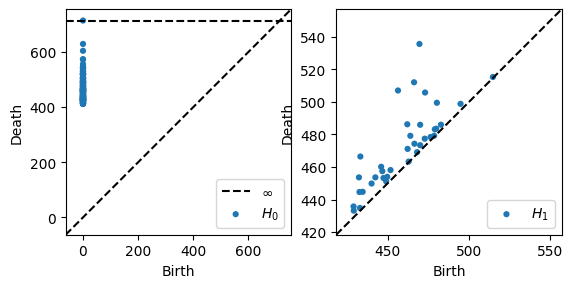

In [88]:
plot_diagrams(dgms, plot_only=[0], ax=plt.subplot(121))
plot_diagrams(dgms, plot_only=[1], ax=plt.subplot(122))

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_705498/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


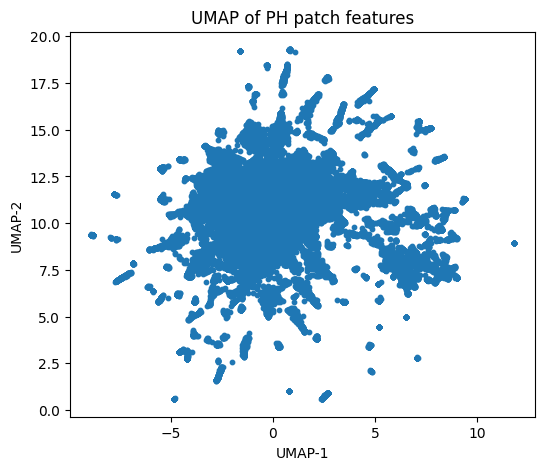

In [5]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

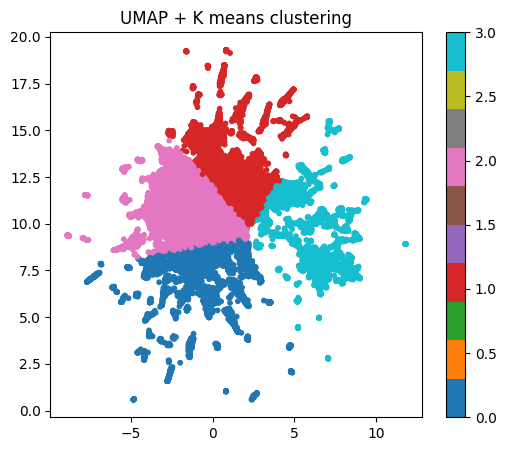

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(embedding)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=labels,
    cmap="tab10",
    s=10
)
plt.title("UMAP + K means clustering")
plt.colorbar()
plt.show()

In [7]:
def get_positions(image_data):

    blocks = view_as_blocks(image_data, block_shape=(16, 16))
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * 16, j * 16)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [8]:
import numpy as np

def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+16, c:c+16] = lab

    return label_img

In [10]:
positions = get_positions(image_data)
label_img = label_to_image(image_data, labels, positions)

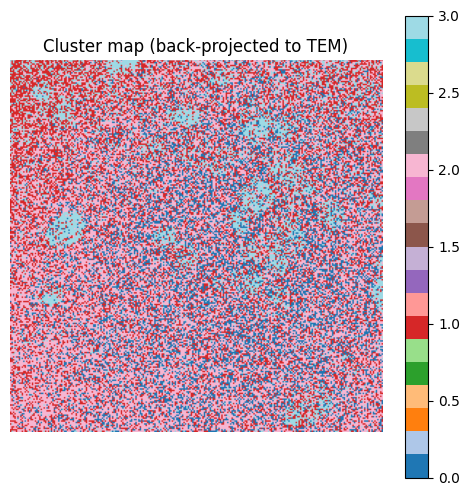

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

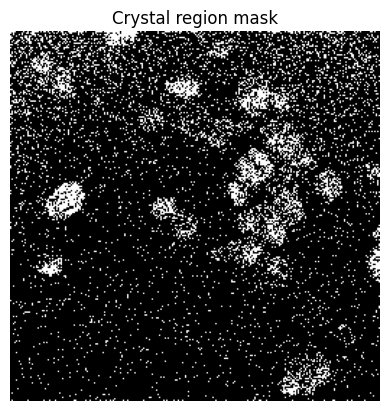

In [25]:
target_cluster = 3  

mask = (label_img == target_cluster).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [26]:
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_97345/3027865136.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


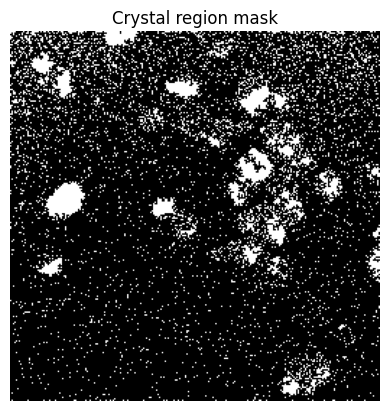

In [27]:
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

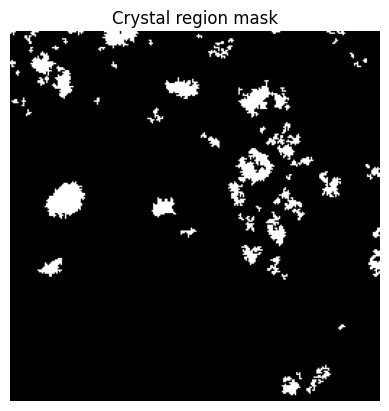

In [28]:
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [29]:
from skimage.metrics import adapted_rand_error

clean_img = clean_mask.astype(np.uint8)


are, precision, recall = adapted_rand_error(clean_img, label_image)

print("Adapted Rand Error:", are)
print("Precision:", precision)
print("Recall:", recall)

NameError: name 'label_image' is not defined

UMAP + GMM

In [19]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, covariance_type="full")
labels = gmm.fit_predict(embedding)

probs = gmm.predict_proba(embedding)

label_img = label_to_image(image_data, labels, positions)

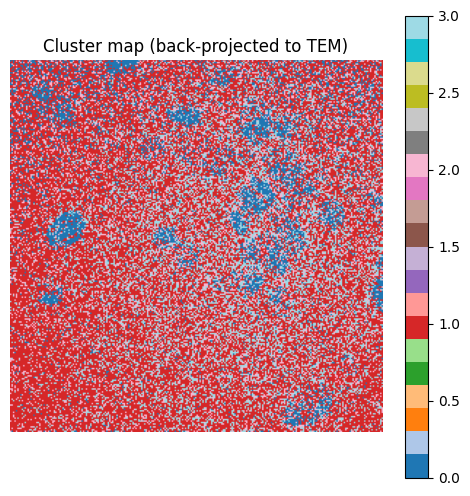

In [20]:
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

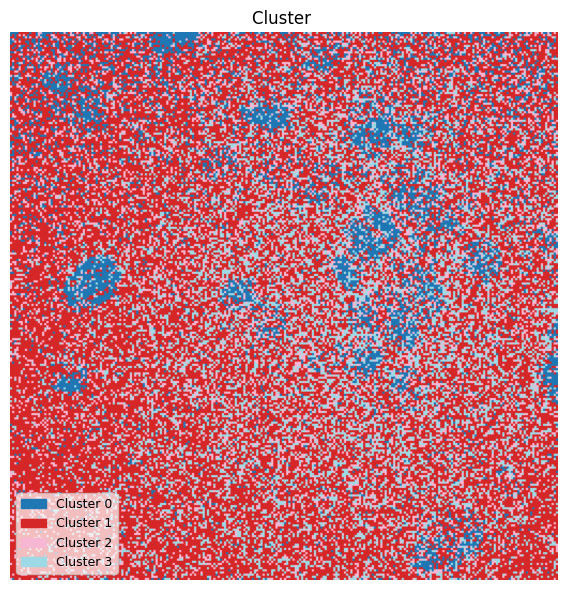

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(6,6))

clusters = np.unique(label_img)
cmap = plt.get_cmap("tab20", len(clusters))

plt.imshow(label_img, cmap=cmap)

plt.title("Cluster ")
plt.axis("off")

legend_patches = [
    mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
    for i, c in enumerate(clusters)
]

plt.legend(
    handles=legend_patches,
    loc="lower left",          # inside plot
    frameon=True,             # box around legend
    framealpha=0.7,           # semi-transparent
    fontsize=9
)

plt.tight_layout()
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_705498/1490235922.py:11: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


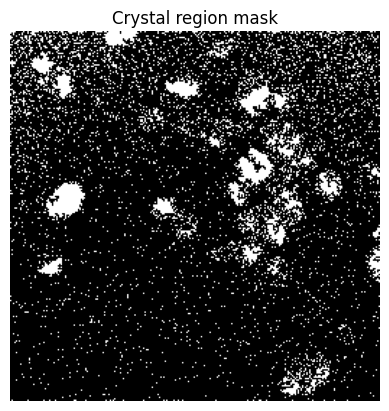

In [51]:
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk

target_cluster = 0

mask = (label_img == target_cluster).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

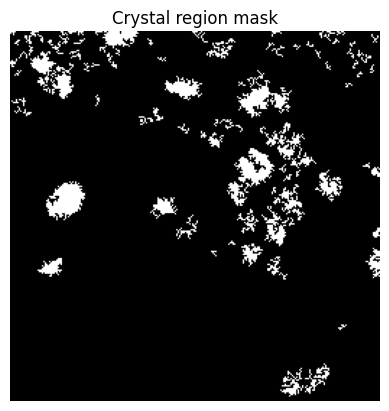

In [52]:
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [50]:
accuracy = np.mean(clean_mask == img) * 100
print(f"Accuracy: {accuracy:.2f}%")       
truth_mask = (img > 0)             

intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              
dice = 2 * intersection / (clean_mask.sum() + truth_mask.sum()) if (clean_mask.sum() + truth_mask.sum()) > 0 else 0.0

intersection = (clean_mask & truth_mask).sum()
    
precision = intersection / clean_mask.sum()                    
recall    = intersection / truth_mask.sum()                         
f1        = 2 * precision * recall / (precision + recall)          

print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")

print(f"IoU: {iou:.3f}  Dice: {dice:.3f}")


Accuracy: 86.79%
Precision: 0.924  Recall: 0.279  F1: 0.429
IoU: 0.273  Dice: 0.429


In [53]:

cluster_patches = split_patches(16, label_img)
cluster_labels = np.array([int(p[0,0]) for p in cluster_patches])

patch_pds = dgms

assert len(cluster_labels) == len(patch_pds), "Mismatch!"

all_patch_data = [
    {
        "pd": pd,
        "cluster": cl,
        "patch": patch
    }
    for pd, cl, patch in zip(patch_pds, cluster_labels, cluster_patches)
]

cluster_ids = np.unique(label_img)
cluster_mean_intensity = {}

for c in cluster_ids:
    mask = (label_img == c)              # pixels in this cluster
    cluster_mean_intensity[c] = image_data[mask].mean()  # mean over original image

crystalline_cluster = min(cluster_mean_intensity, key=cluster_mean_intensity.get)
print("Crystalline cluster ID:", crystalline_cluster)

cluster_representatives = {}

for c in np.unique(cluster_labels):

    vecs = np.array([
        pimgr.transform(d["pd"]).ravel()
        for d in all_patch_data
        if d["cluster"] == c
    ])

    pds = [
        d["pd"]
        for d in all_patch_data
        if d["cluster"] == c
    ]

    centroid = vecs.mean(axis=0)
    idx = np.argmin(np.linalg.norm(vecs - centroid, axis=1))

    cluster_representatives[c] = pds[idx]

crystalline_pd = cluster_representatives[crystalline_cluster]

Crystalline cluster ID: 0


In [23]:
print("Unique cluster labels in data:", np.unique(cluster_labels))
print("Clusters in representatives:", cluster_representatives.keys())
print("Expected clusters:", set(range(4)))

Unique cluster labels in data: [0 1 2 3]
Clusters in representatives: dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3)])
Expected clusters: {0, 1, 2, 3}


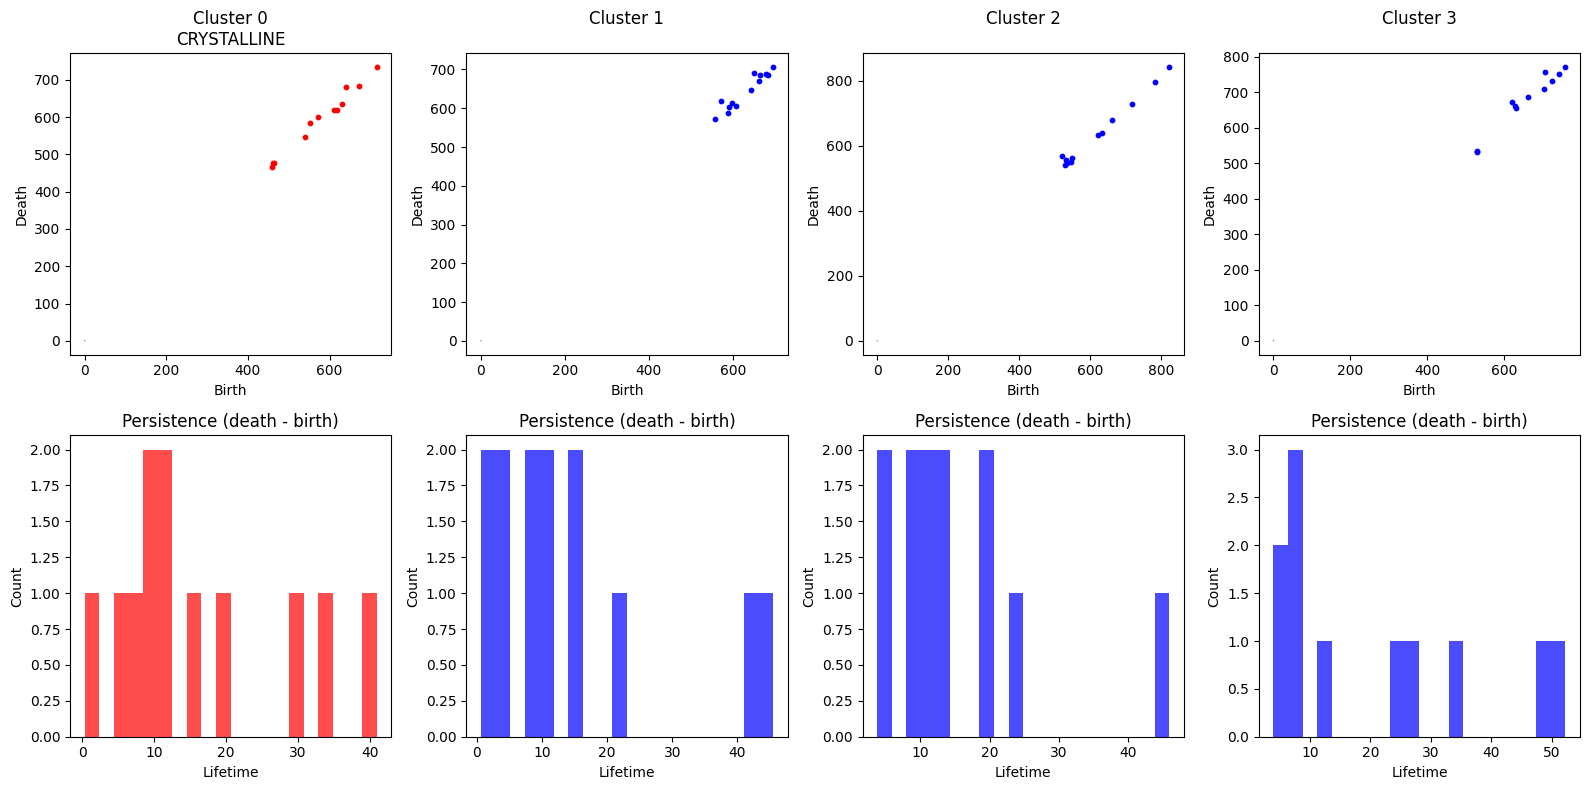

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import gudhi

clusters = sorted(cluster_representatives.keys())
n = len(clusters)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

if n == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # ensure 2D indexing

for i, c in enumerate(clusters):

    pd = np.array(cluster_representatives[c])

    ax = axes[0, i]

    ax.scatter(
        pd[:, 0],
        pd[:, 1],
        c='red' if c == crystalline_cluster else 'blue',
        s=10
    )

    ax.set_title(
        f"Cluster {c}\n"
        + ("CRYSTALLINE" if c == crystalline_cluster else "")
    )

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)

    ax2 = axes[1, i]

    lifetimes = pd[:, 1] - pd[:, 0]

    ax2.hist(
        lifetimes,
        bins=20,
        color='red' if c == crystalline_cluster else 'blue',
        alpha=0.7
    )

    ax2.set_title("Persistence (death - birth)")
    ax2.set_xlabel("Lifetime")
    ax2.set_ylabel("Count")



plt.tight_layout()
plt.show()

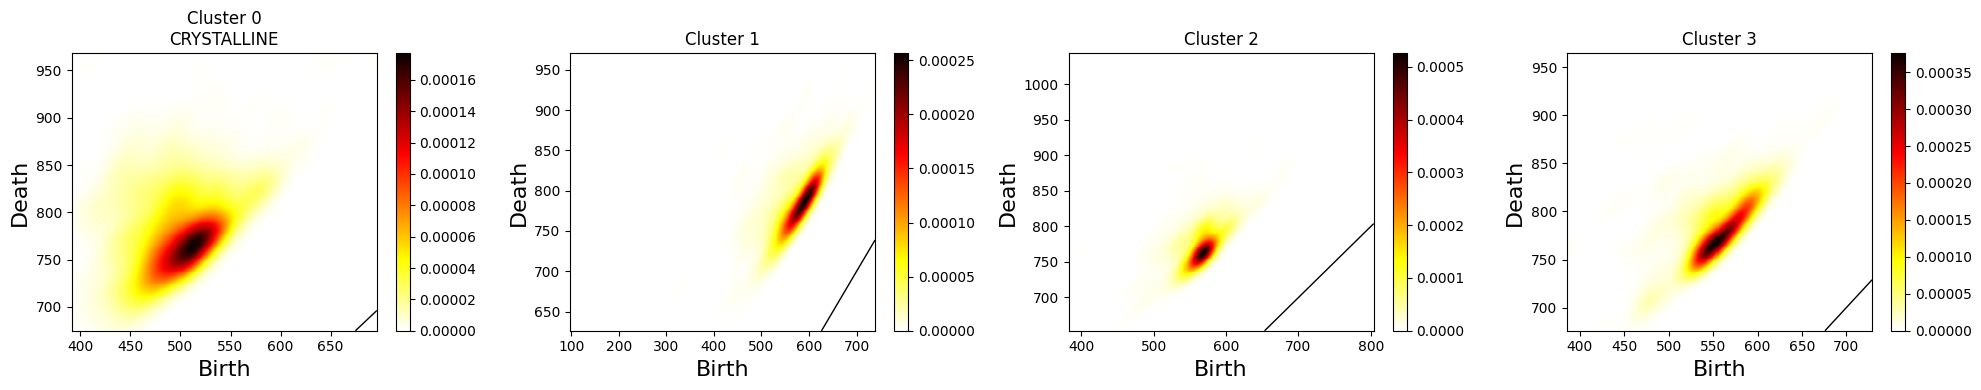

In [31]:
import gudhi
cluster_persistence_points = {}

for c in np.unique(cluster_labels):

    pds = [
        d["pd"]
        for d in all_patch_data
        if d["cluster"] == c
    ]

    # concatenate all persistence points
    cluster_pd = np.vstack([
        np.asarray(pd)
        for pd in pds
        if len(pd) > 0
    ])

    cluster_persistence_points[c] = cluster_pd


all_points = np.vstack(
    list(cluster_persistence_points.values())
)


fig, axes = plt.subplots(
    1,
    len(clusters),
    figsize=(5 * len(clusters), 4)
)

if len(clusters) == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):

    pd = cluster_persistence_points[c]

    gudhi.plot_persistence_density(
        pd,
        axes=ax
    )

    ax.set_title(
        f"Cluster {c}"
        + ("\nCRYSTALLINE" if c == crystalline_cluster else "")
    )

plt.tight_layout()
plt.show()

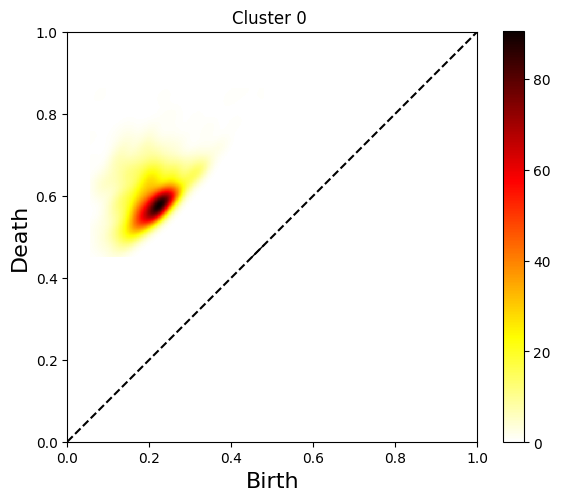

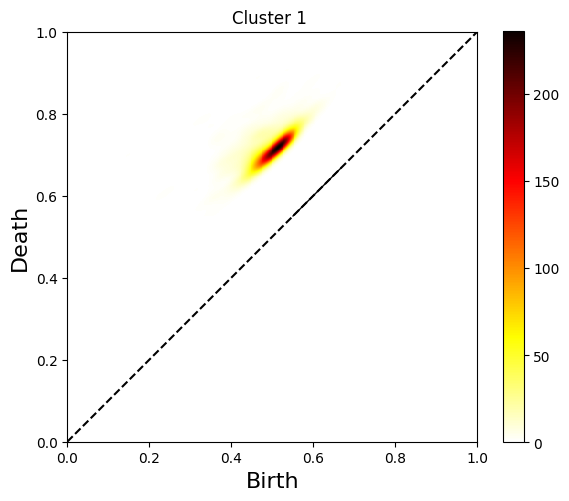

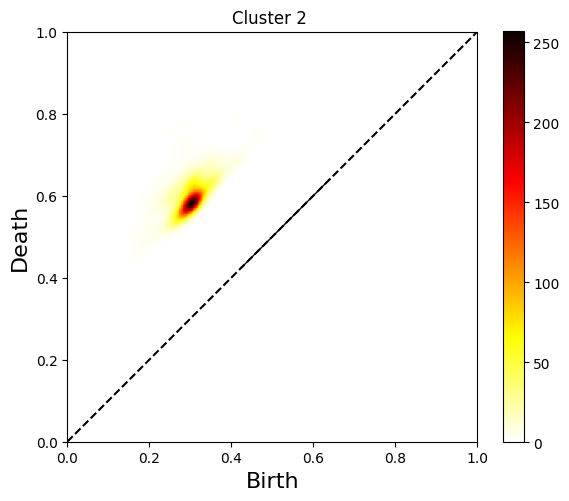

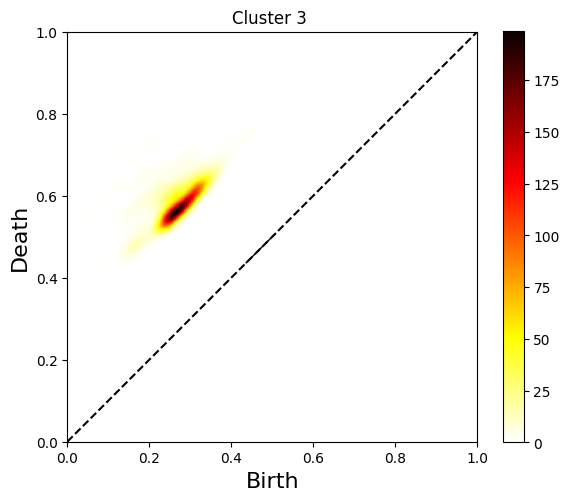

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi

for c in sorted(cluster_persistence_points):

    pd = cluster_persistence_points[c].astype(float)

    min_val = pd.min()
    max_val = pd.max()

    pd_norm = (pd - min_val) / (max_val - min_val + 1e-12)

    fig, ax = plt.subplots(figsize=(6, 5))

    gudhi.plot_persistence_density(pd_norm, axes=ax)

    # diagonal (now in [0,1])
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_aspect('equal', adjustable='box')

    ax.set_title(f"Cluster {c} ")

    plt.tight_layout()
    plt.show()
    

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


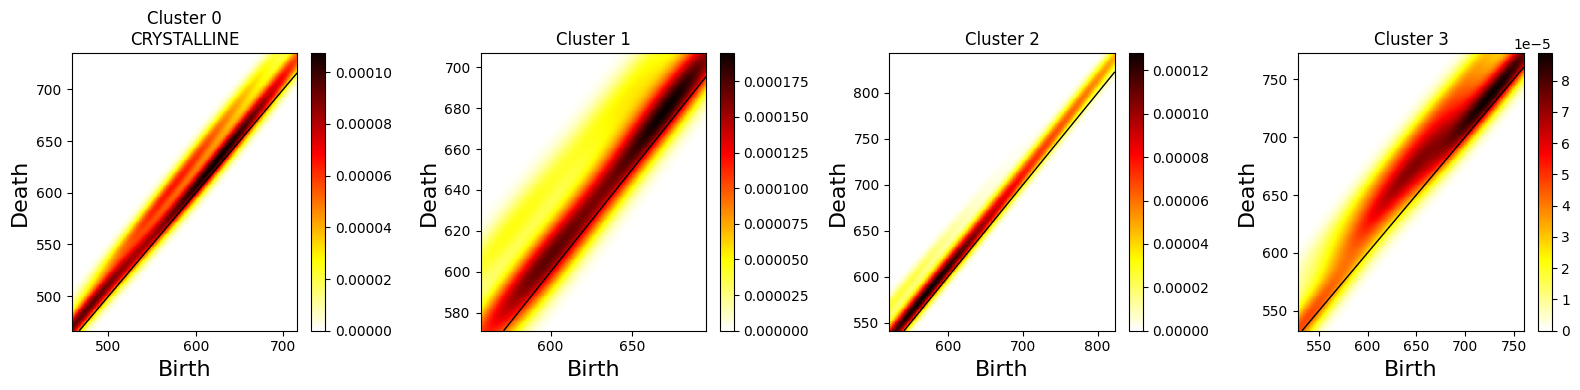

In [25]:
from gudhi import plot_persistence_density
import matplotlib.pyplot as plt
import numpy as np

clusters = sorted(cluster_representatives.keys())
n = len(clusters)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for i, c in enumerate(clusters):

    pd = np.array(cluster_representatives[c])

    plt.sca(axes[i])

    plot_persistence_density(
        pd,
        axes=axes[i]
    )

    axes[i].set_title(
        f"Cluster {c}"
        + ("\nCRYSTALLINE" if c == crystalline_cluster else "")
    )

plt.tight_layout()
plt.show()

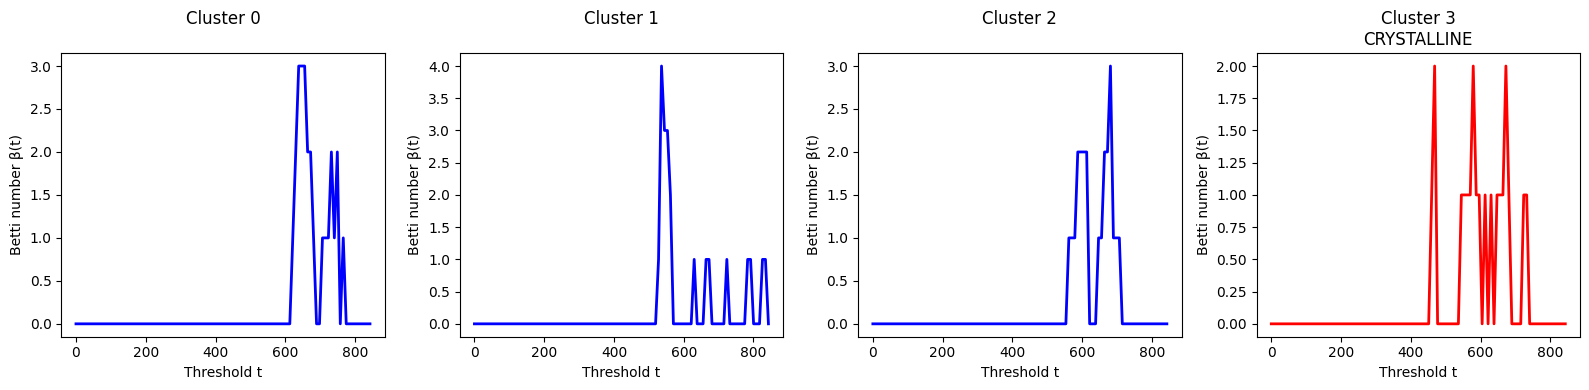

In [49]:
import numpy as np
import matplotlib.pyplot as plt

clusters = sorted(cluster_representatives.keys())
n = len(clusters)

# Define thresholds (uniform grid from 0 to max death across all clusters)
max_death = max(np.max(np.array(cluster_representatives[c])[:,1]) for c in clusters)
thresholds = np.linspace(0, max_death, 100)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):
    pd = np.array(cluster_representatives[c])
    
    # Compute Betti curve (H1 features)
    betti = []
    for t in thresholds:
        count = np.sum((pd[:,0] <= t) & (pd[:,1] > t))
        betti.append(count)
    
    ax.plot(thresholds, betti, color='red' if c == crystalline_cluster else 'blue', lw=2)
    ax.set_title(f"Cluster {c}\n" + ("CRYSTALLINE" if c == crystalline_cluster else ""))
    ax.set_xlabel("Threshold t")
    ax.set_ylabel("Betti number β(t)")

plt.tight_layout()
plt.show()

In [ ]:
lifespans = {
    c: np.array([d[1] - d[0] for d in cluster_pds[c]])
    for c in cluster_pds
}

for c in lifespans:
    plt.hist(lifespans[c], bins=30, alpha=0.5, label=f"cluster {c}")
plt.legend()
plt.title("Persistence (death - birth) distribution")
plt.show()

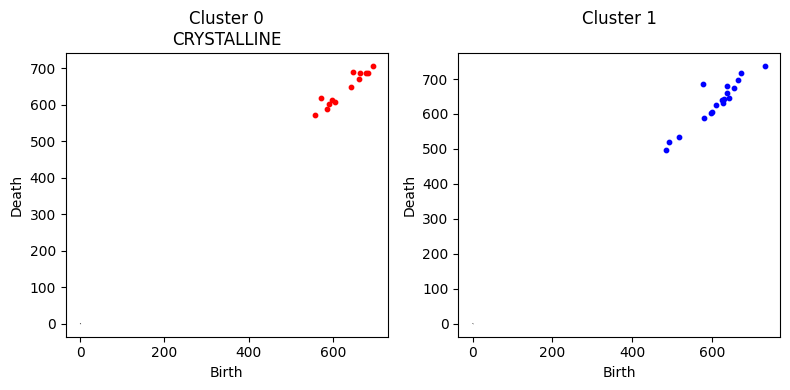

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

clusters = sorted(cluster_representatives.keys())
n = len(clusters)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):

    pd = cluster_representatives[c]

    pd = np.array(pd)

    ax.scatter(
        pd[:, 0],
        pd[:, 1],
        c='red' if c == crystalline_cluster else 'blue',
        s=10
    )

    ax.set_title(
        f"Cluster {c}\n"
        + ("CRYSTALLINE" if c == crystalline_cluster else "")
    )

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)  # diagonal reference

plt.tight_layout()
plt.show()

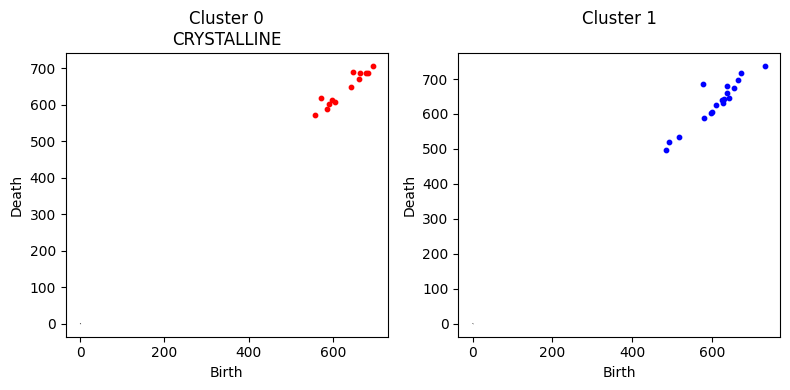

In [37]:
import matplotlib.pyplot as plt
import numpy as np

clusters = sorted(cluster_representatives.keys())
n = len(clusters)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for ax, c in zip(axes, clusters):

    pd = cluster_representatives[c]

    pd = np.array(pd)

    ax.scatter(
        pd[:, 0],
        pd[:, 1],
        c='red' if c == crystalline_cluster else 'blue',
        s=10
    )

    ax.set_title(
        f"Cluster {c}\n"
        + ("CRYSTALLINE" if c == crystalline_cluster else "")
    )

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)  # diagonal reference

plt.tight_layout()
plt.show()

UMAP + HDBSCAN

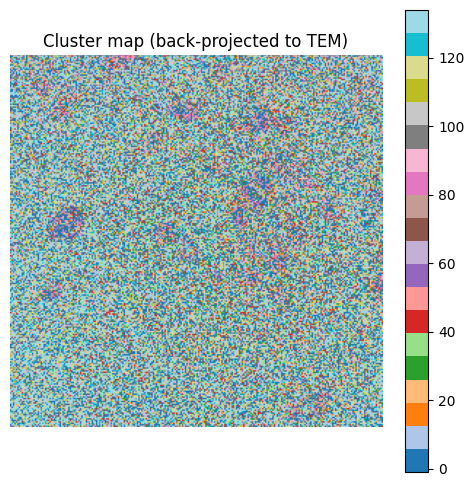

In [107]:
import hdbscan

labels = hdbscan.HDBSCAN(
    min_cluster_size=50
).fit_predict(embedding)

label_img = label_to_image(image_data, labels, positions)

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

In [109]:
unique, counts = np.unique(labels, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} points")

Cluster -1: 11655 points
Cluster 0: 165 points
Cluster 1: 84 points
Cluster 2: 116 points
Cluster 3: 161 points
Cluster 4: 235 points
Cluster 5: 51 points
Cluster 6: 126 points
Cluster 7: 475 points
Cluster 8: 232 points
Cluster 9: 62 points
Cluster 10: 108 points
Cluster 11: 96 points
Cluster 12: 121 points
Cluster 13: 59 points
Cluster 14: 397 points
Cluster 15: 130 points
Cluster 16: 96 points
Cluster 17: 90 points
Cluster 18: 161 points
Cluster 19: 68 points
Cluster 20: 82 points
Cluster 21: 84 points
Cluster 22: 86 points
Cluster 23: 72 points
Cluster 24: 133 points
Cluster 25: 485 points
Cluster 26: 365 points
Cluster 27: 596 points
Cluster 28: 203 points
Cluster 29: 59 points
Cluster 30: 147 points
Cluster 31: 52 points
Cluster 32: 53 points
Cluster 33: 622 points
Cluster 34: 891 points
Cluster 35: 123 points
Cluster 36: 110 points
Cluster 37: 166 points
Cluster 38: 94 points
Cluster 39: 1092 points
Cluster 40: 55 points
Cluster 41: 135 points
Cluster 42: 128 points
Cluster 43: 

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_43600/2152952435.py:5: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


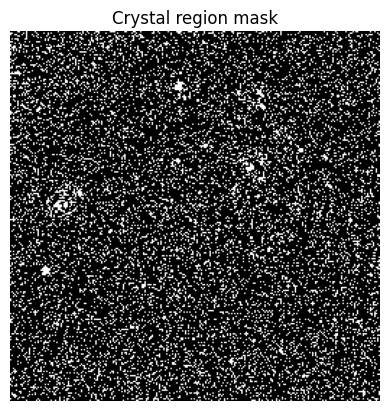

In [114]:


mask = ((label_img == -1) | (label_img == 90)).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

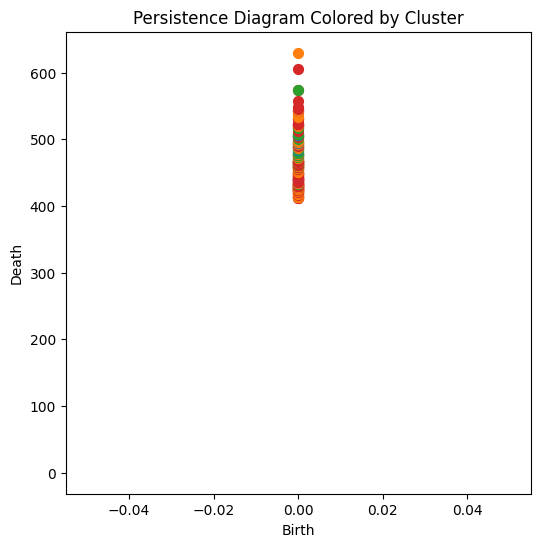

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

points = vectorised_patches
cluster_labels = labels         

diagrams = ripser(vectorised_patches, maxdim=1,n_perm=200)['dgms']

plt.figure(figsize=(6,6))
colors = plt.cm.tab10(cluster_labels % 10)  

h0 = diagrams[0]

for idx, (b,d) in enumerate(h0):
    plt.scatter(b, d, color=colors[idx], s=50)

plt.plot([0, max(h0[:,1])], [0, max(h0[:,1])], 'k--')  # diagonal
plt.xlabel("Birth")
plt.ylabel("Death")
plt.title("Persistence Diagram Colored by Cluster")
plt.show()

In [25]:
import numpy as np

cluster_ids = np.unique(labels)
cluster_avgs = {}

for c in cluster_ids:
    cluster_avgs[c] = vectorised_patches[labels == c].mean(axis=0)

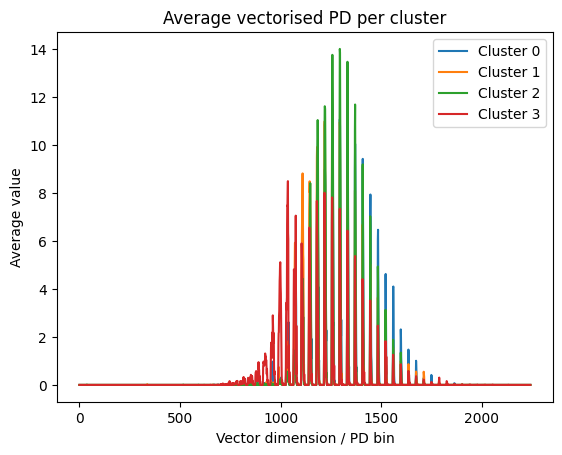

In [26]:
import matplotlib.pyplot as plt

for c in cluster_ids:
    plt.plot(cluster_avgs[c], label=f"Cluster {c}")

plt.xlabel("Vector dimension / PD bin")
plt.ylabel("Average value")
plt.title("Average vectorised PD per cluster")
plt.legend()
plt.show()